https://www.kaggle.com/code/mingdi22/pytorch-tutorial-for-deep-learning-lovers/edit

In [245]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print(os.listdir("input/"))

['test.csv', 'sample_submission.csv', 'train.csv']


# 基础知识

In [246]:
import numpy as np

array = [[1,2,3],
        [4,5,6]]

first_arry = np.array(array)
print("Array Type:{}".format(type(first_arry)))
print("Array shape:{}".format(np.shape(first_arry)))
print(first_arry)

Array Type:<class 'numpy.ndarray'>
Array shape:(2, 3)
[[1 2 3]
 [4 5 6]]


In [247]:
import torch

In [248]:
tensor = torch.Tensor(array)
print("Array Type:{}".format(tensor.type))
print("Array shape:{}".format(tensor.shape))
print(tensor)

Array Type:<built-in method type of Tensor object at 0x7b1fe3101220>
Array shape:torch.Size([2, 3])
tensor([[1., 2., 3.],
        [4., 5., 6.]])


In [249]:
print("Numpy {}\n".format(np.ones((2,3))))

print(torch.ones((2,3)))

Numpy [[1. 1. 1.]
 [1. 1. 1.]]

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [250]:
print("Numpy {}\n".format(np.random.rand(2,3)))

print(torch.rand(2,3))

Numpy [[0.7363609  0.50225957 0.51406269]
 [0.00607674 0.74114112 0.04541532]]

tensor([[0.1405, 0.7672, 0.3929],
        [0.4319, 0.3196, 0.9924]])


## 张量和numpy相互转换

In [251]:
array = np.random.rand(2, 2)
print("{} {}\n".format(type(array), array))

# from numpy to tensor
from_numpy_to_tensor = torch.from_numpy(array)
print("{}\n".format(from_numpy_to_tensor))

# from tensor to numpy
tensor = from_numpy_to_tensor
from_tensor_to_numpy = tensor.numpy()
print("{} {}\n".format(type(from_tensor_to_numpy), from_tensor_to_numpy))

<class 'numpy.ndarray'> [[0.67841079 0.5507934 ]
 [0.36215973 0.45762448]]

tensor([[0.6784, 0.5508],
        [0.3622, 0.4576]], dtype=torch.float64)

<class 'numpy.ndarray'> [[0.67841079 0.5507934 ]
 [0.36215973 0.45762448]]



# 使用pytorch进行基础学习

调整大小：view()

a 和 b 是张量。

加法：torch.add(a,b) = a + b

减法：a.sub(b) = a - b

元素乘法：torch.mul(a,b) = a * b

元素除法：torch.div(a,b) = a / b

平均值：a.mean()

标准差 (std)：a.std()

In [252]:
tensor = torch.ones(3,3)

print(tensor.view(9).shape)
print("{}{}\n".format(tensor.view(9).shape, tensor.view(9)))

torch.Size([9])
torch.Size([9])tensor([1., 1., 1., 1., 1., 1., 1., 1., 1.])



In [253]:
print("Addition:{}\n".format(torch.add(tensor, tensor)))

Addition:tensor([[2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.]])



In [254]:
print("Subtraction: {}\n".format(tensor.sub(tensor)))

Subtraction: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])



In [255]:
print("Element wise multiplication:{}\n".format(torch.mul(tensor, tensor)))

Element wise multiplication:tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])



In [256]:
print("Element wise division:{}".format(torch.div(tensor, tensor)))

Element wise division:tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


In [257]:
tensor = torch.Tensor([1,2,3,4,5])
print("Mean:{}".format(tensor.mean()))

Mean:3.0


In [258]:
print("std:{}".format(tensor.std()))

std:1.5811388492584229


## 变量

In [259]:
from torch.autograd import Variable

var = Variable(torch.ones(3), requires_grad = True)
var

tensor([1., 1., 1.], requires_grad=True)

In [260]:
array = [2, 4]
tensor = torch.Tensor(array)
x = Variable(tensor, requires_grad=True)
y = x**2
print("y = ", y)

y =  tensor([ 4., 16.], grad_fn=<PowBackward0>)


In [261]:
o = (1/2) * sum(y)
print("o = ",o)
o.backward()
print("gradients: ", x.grad)

o =  tensor(10., grad_fn=<MulBackward0>)
gradients:  tensor([2., 4.])


# 线性回归

In [262]:
car_prices_array = [3,4,5,6,7,8,9]
car_price_np = np.array(car_prices_array, dtype=np.float32)
car_price_np = car_price_np.reshape(-1, 1)
car_price_tensor = Variable(torch.from_numpy(car_price_np))

In [263]:
number_of_car_sell_array = [7.5,7, 6.5, 6,5.5,5,4.5]
number_of_car_sell_np = np.array(number_of_car_sell_array, dtype=np.float32)
number_of_car_sell_np = number_of_car_sell_np.reshape(-1, 1)
number_of_car_sell_tensor = Variable(torch.from_numpy(number_of_car_sell_np))

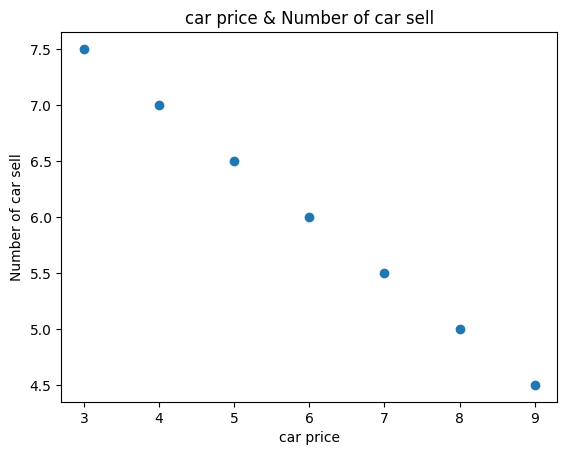

In [264]:
import matplotlib.pyplot as plt
plt.scatter(car_prices_array, number_of_car_sell_array)
plt.xlabel("car price")
plt.ylabel("Number of car sell")
plt.title("car price & Number of car sell")
plt.show()

In [265]:
import torch
from torch.autograd import Variable
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")

In [266]:
class LinearRegression(nn.Module):
    
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        return self.linear(x)

In [267]:
input_dim = 1
output_dim = 1
model = LinearRegression(input_dim, output_dim)

In [268]:
mse = nn.MSELoss()

这段代码是用来创建一个随机梯度下降（Stochastic Gradient Descent，SGD）优化器的。在 PyTorch 中，优化器是用于更新模型参数以最小化损失函数的工具。下面是对这段代码的详细讲解：

1. **torch.optim.SGD**: 这是 PyTorch 中实现的一个优化器类，专门用于随机梯度下降算法。SGD 是一种常见的优化算法，特别适用于神经网络训练。它通过计算模型参数的梯度并使用这些梯度来调整参数，从而帮助模型在训练过程中逐步收敛到一个更优的解。

2. **model.parameters()**: 这个方法返回模型中所有需要优化的参数（例如，神经网络中的权重和偏置）。`model` 是一个神经网络模型的实例，这些参数将被优化器所管理。

3. **lr=learning_rate**: 这是设置学习率（learning rate）参数的部分。学习率是一个超参数，它决定了模型在每一次参数更新时走多大一步。合适的学习率可以加速收敛，但如果学习率太大，可能会导致不稳定或者发散；如果太小，可能会导致收敛速度过慢。

完整的代码可以理解为：创建一个 SGD 优化器，用于优化 `model` 的参数，其中学习率设为 `learning_rate`。接下来，通常会在训练循环中调用这个优化器的步骤方法（如 `optimizer.step()`），以更新模型参数。


In [269]:
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)                           

In [270]:
loss_list = []
iteration_number = 1001

好的，下面是对每一行代码的详细解析：

```python
for iteration in range(iteration_number):
```
这一行用于初始化一个循环，该循环将执行 `iteration_number` 次。`iteration` 变量会在每次循环中依次取 0 到 `iteration_number - 1` 的值，表示当前的迭代次数。

```python
    optimizer.zero_grad()
```
这个语句用于将优化器中所有参数的梯度置零。在每次迭代开始时，需要清除上一步的梯度，以便在新的前向传播中计算新的梯度。

```python
    results = model(car_price_tensor)
```
这一行将输入数据 `car_price_tensor` 传入模型 `model` 中进行前向传播，获取模型的输出结果 `results`。`car_price_tensor` 可能是经过处理的汽车价格数据。

```python
    loss = mse(results, number_of_car_sell_tensor)
```
在这一行中，计算预测结果 `results` 和真实标签 `number_of_car_sell_tensor` 之间的损失值，使用均方误差 (MSE) 作为损失函数。这个损失值用于衡量模型预测的准确度。

```python
    loss.backward()
```
这行代码进行反向传播，计算损失函数对模型参数的梯度。通过调用 `.backward()`，PyTorch 将自动计算每个参数的梯度。

```python
    optimizer.step()
```
调用优化器的 `step()` 方法更新模型参数。这个操作会根据计算得到的梯度调整模型的权重，以减少损失。

```python
    loss_list.append(loss.data)
```
将当前迭代计算得到的损失值添加到 `loss_list` 列表中，`loss.data` 提取出损失值的数值。这有助于后续对损失进行可视化或分析。

```python
    if(iteration % 50 == 0):
        print("epoch {}, loss {}".format(iteration, loss.data))
```
每隔 50 次迭代打印一次当前的迭代次数和对应的损失值。这有助于观察训练过程中的变化。

```python
plt.plot(range(iteration_number), loss_list)
```
使用 Matplotlib 库将迭代次数与对应的损失值进行绘图，以便可视化损失随时间变化的趋势。

```python
plt.xlabel("number of iterations")
```
为 x 轴添加标签 “number of iterations”，说明 x 轴代表的是迭代次数。

```python
plt.ylabel("loss")
```
为 y 轴添加标签 “loss”，说明 y 轴代表的是对应的损失值。

```python
plt.show()
```
最后一行用于显示绘制好的图形，使得用户可以看到训练过程中损失的变化情况。

总体而言，这段代码主要是用于训练一个模型，循环执行前向传播、计算损失、反向传播和参数更新，同时记录损失值以便进行后续的分析和可视化。


epoch 0, loss 74.67913055419922
epoch 50, loss 4.256973743438721
epoch 100, loss 2.8766160011291504
epoch 150, loss 1.9438493251800537
epoch 200, loss 1.3135402202606201
epoch 250, loss 0.8876136541366577
epoch 300, loss 0.5997973680496216
epoch 350, loss 0.4053083062171936
epoch 400, loss 0.27388352155685425
epoch 450, loss 0.1850748360157013
epoch 500, loss 0.1250630021095276
epoch 550, loss 0.08451078087091446
epoch 600, loss 0.05710757523775101
epoch 650, loss 0.03859034553170204
epoch 700, loss 0.026077330112457275
epoch 750, loss 0.017621273174881935
epoch 800, loss 0.011907381005585194
epoch 850, loss 0.008046369068324566
epoch 900, loss 0.005437357816845179
epoch 950, loss 0.0036742540542036295
epoch 1000, loss 0.002482834504917264


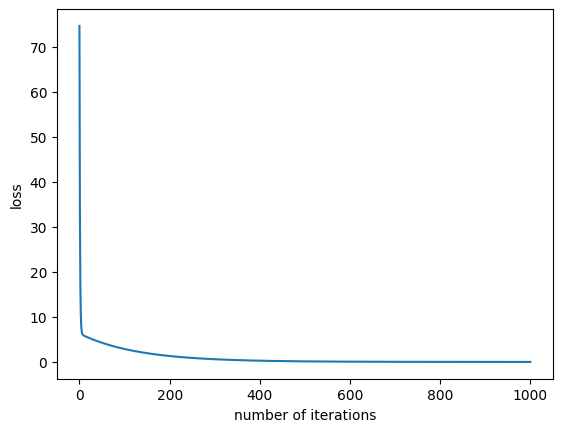

In [271]:
for iteration in range(iteration_number):
    
    optimizer.zero_grad()
    
    results = model(car_price_tensor)
    
    loss = mse(results, number_of_car_sell_tensor)
    
    loss.backward()
    
    optimizer.step()
    
    loss_list.append(loss.data)
    
    if(iteration % 50 == 0):
        print("epoch {}, loss {}".format(iteration, loss.data))
        
plt.plot(range(iteration_number), loss_list)
plt.xlabel("number of iterations")
plt.ylabel("loss")
plt.show()

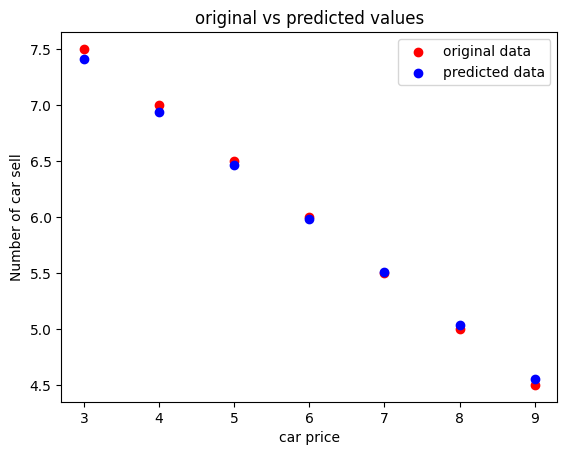

In [272]:
predicted = model(car_price_tensor).data.numpy()
plt.scatter(car_prices_array, number_of_car_sell_array, label="original data", color="red")
plt.scatter(car_prices_array, predicted, label="predicted data", color="blue")

plt.legend()
plt.xlabel("car price")
plt.ylabel("Number of car sell")
plt.title("original vs predicted values")
plt.show()

# 逻辑回归

In [273]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

In [274]:
train = pd.read_csv(r"input/train.csv", dtype=np.float32)
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [275]:
targers_numpy = train.label.values
targers_numpy[:5]

array([1., 0., 1., 4., 0.], dtype=float32)

In [276]:
features_numpy = train.loc[:, train.columns != "label"].values / 255

In [277]:
features_train, features_test, targets_train, targets_test = train_test_split(features_numpy,
                                                                             targers_numpy,
                                                                             test_size=0.2,
                                                                             random_state=42)

In [278]:
featuresTrain = torch.from_numpy(features_train)
targetsTrain = torch.from_numpy(targets_train).type(torch.LongTensor)

In [279]:
featuresTest = torch.from_numpy(features_test)
targetsTest = torch.from_numpy(targets_test).type(torch.LongTensor)

In [280]:
batch_size = 100
n_iters = 10000
num_epochs = n_iters / (len(features_train) / batch_size)
num_epochs = int(num_epochs)

In [281]:
train = torch.utils.data.TensorDataset(featuresTrain, targetsTrain)
test = torch.utils.data.TensorDataset(featuresTest, targetsTest)

In [282]:
train_loader = DataLoader(train, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

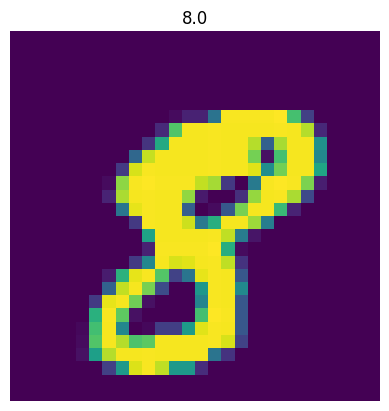

In [283]:
plt.imshow(features_numpy[10].reshape(28, 28))
plt.axis("off")
plt.title(str(targers_numpy[10]))
plt.savefig('graph.png')
plt.show()

In [284]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        out = self.linear(x)
        return out

In [285]:
input_dim = 28*28
output_dim = 10

In [286]:
model = LogisticRegressionModel(input_dim, output_dim)
error = nn.CrossEntropyLoss()

In [287]:
learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [288]:
count = 0
loss_list = []
iteration_list = []

In [289]:
for epoch in range(num_epochs):
     for i, (images, labels) in enumerate(train_loader):
            train = Variable(images.view(-1, 28*28))
            labels = Variable(labels)
            
            optimizer.zero_grad()
            
            outputs = model(train)
            
            loss = error(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            count += 1
            
            if count % 50 == 0:
                correct = 0
                total = 0
                for images, labels in test_loader:
                    test = Variable(images.view(-1, 28*28))
                    
                    outputs = model(test)
                    
                    predicted = torch.max(outputs.data, 1)[1]
                    
                    total += len(labels)
                    
                    correct += (predicted == labels).sum()
                    
                accuracy = 100 * correct / float(total)
                
                loss_list.append(loss.data)
                iteration_list.append(count)
            if count % 500 == 0:
                print('Iteration:{} Loss:{:.2f} Accuracy:{:.2f}%'.format(count, loss.data, accuracy))

Iteration:500 Loss:1.79 Accuracy:71.06%
Iteration:1000 Loss:1.59 Accuracy:76.95%
Iteration:1500 Loss:1.27 Accuracy:78.88%
Iteration:2000 Loss:1.19 Accuracy:80.15%
Iteration:2500 Loss:1.03 Accuracy:81.13%
Iteration:3000 Loss:0.93 Accuracy:81.81%
Iteration:3500 Loss:0.90 Accuracy:82.40%
Iteration:4000 Loss:0.74 Accuracy:83.02%
Iteration:4500 Loss:0.98 Accuracy:83.55%
Iteration:5000 Loss:0.81 Accuracy:84.00%
Iteration:5500 Loss:0.74 Accuracy:84.32%
Iteration:6000 Loss:0.87 Accuracy:84.52%
Iteration:6500 Loss:0.66 Accuracy:84.75%
Iteration:7000 Loss:0.72 Accuracy:84.99%
Iteration:7500 Loss:0.64 Accuracy:85.19%
Iteration:8000 Loss:0.73 Accuracy:85.36%
Iteration:8500 Loss:0.55 Accuracy:85.55%
Iteration:9000 Loss:0.66 Accuracy:85.67%
Iteration:9500 Loss:0.53 Accuracy:85.71%


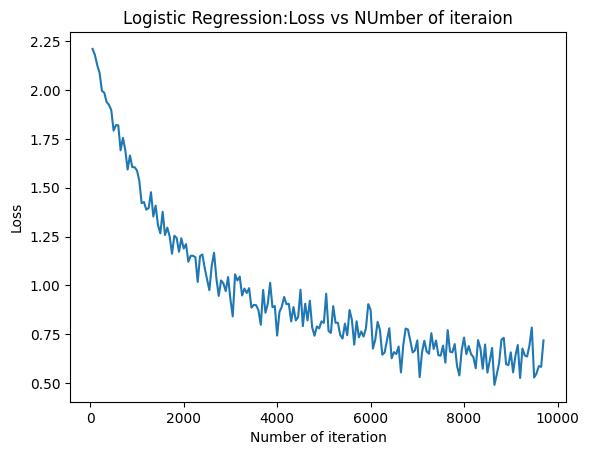

In [290]:
plt.plot(iteration_list, loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Logistic Regression:Loss vs NUmber of iteraion")
plt.show()

# 人工神经网络（ANN）

In [291]:
import torch
import torch.nn as nn
from torch.autograd import Variable

In [292]:
class ANNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.tanh2 = nn.Tanh()
        
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.elu3 = nn.ELU()
        
        self.fc4 = nn.Linear(hidden_dim,output_dim)
        
    def forward(self, x):
        
        out = self.fc1(x)
        out = self.relu1(out)
        
        out = self.fc2(out)
        out = self.tanh2(out)
        
        out = self.fc3(out)
        out = self.elu3(out)
        
        out = self.fc4(out)
        return out

In [293]:
input_dim = 28*28
hidden_dim = 150
output_dim = 10

In [294]:
model = ANNModel(input_dim, hidden_dim, output_dim)

In [295]:
error = nn.CrossEntropyLoss()

In [296]:
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, )

In [297]:
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

In [298]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        
        train = Variable(images.view(-1, 28*28))
        labels = Variable(labels)
        
        optimizer.zero_grad()
        
        outputs = model(train)
        
        loss = error(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        count += 1
        
        if count % 50 == 0:
            correct = 0
            total = 0
           
            for images, labels in test_loader:
                
                test = Variable(images.view(-1, 28*28))
                
                outputs = model(test)
                
                predicted = torch.max(outputs.data, 1)[1]
                
                total += len(labels)
                
                correct += (predicted == labels).sum()\
                
            accuracy = 100 * correct / float(total)
            
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)
        if count % 500 == 0:
            print("Iteraion:{} Loss:{:.5f}, Accuracy:{:.2f}%".format(count, loss.data, accuracy))

Iteraion:500 Loss:0.83223, Accuracy:78.56%
Iteraion:1000 Loss:0.45418, Accuracy:87.67%
Iteraion:1500 Loss:0.24050, Accuracy:89.58%
Iteraion:2000 Loss:0.29007, Accuracy:90.58%
Iteraion:2500 Loss:0.30943, Accuracy:91.93%
Iteraion:3000 Loss:0.12134, Accuracy:92.60%
Iteraion:3500 Loss:0.23162, Accuracy:93.43%
Iteraion:4000 Loss:0.07121, Accuracy:93.86%
Iteraion:4500 Loss:0.32643, Accuracy:94.49%
Iteraion:5000 Loss:0.10804, Accuracy:94.77%
Iteraion:5500 Loss:0.18281, Accuracy:94.86%
Iteraion:6000 Loss:0.18873, Accuracy:95.04%
Iteraion:6500 Loss:0.09569, Accuracy:95.29%
Iteraion:7000 Loss:0.11049, Accuracy:95.77%
Iteraion:7500 Loss:0.10809, Accuracy:95.62%
Iteraion:8000 Loss:0.16575, Accuracy:95.69%
Iteraion:8500 Loss:0.07412, Accuracy:96.06%
Iteraion:9000 Loss:0.05278, Accuracy:96.02%
Iteraion:9500 Loss:0.02396, Accuracy:96.19%


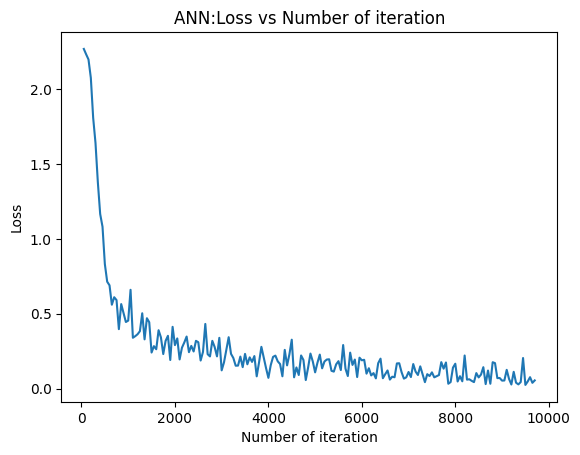

In [299]:
plt.plot(iteration_list, loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN:Loss vs Number of iteration")
plt.show()

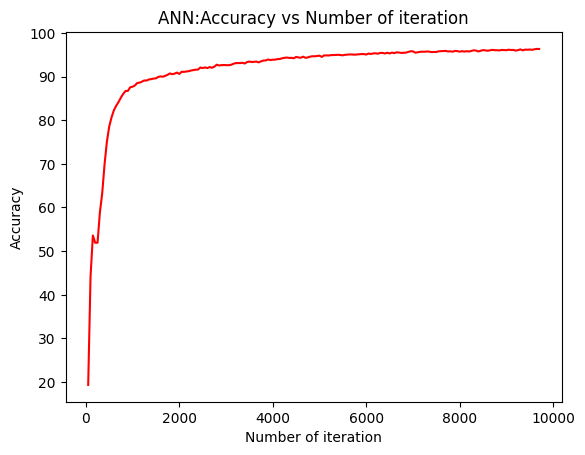

In [300]:
plt.plot(iteration_list, accuracy_list, color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN:Accuracy vs Number of iteration")
plt.show()

# 卷积神经网络

In [301]:
import torch
import torch.nn as nn
from torch.autograd import Variable

In [336]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()
        
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()
        
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        
        self.fc1 = nn.Linear(32 * 4* 4, 10)
        
    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        
        out = self.maxpool1(out)
        
        out = self.cnn2(out)
        out = self.relu2(out)
        
        out = self.maxpool2(out)
        
        out = out.view(out.size(0), -1)
        
        out = self.fc1(out)
        
        return out

In [325]:
batch_size = 100
n_iters = 2500
num_epochs = n_iters / (len(features_train) / batch_size)
num_epochs = int(num_epochs)

In [337]:
train = torch.utils.data.TensorDataset(featuresTrain,targetsTrain)
test = torch.utils.data.TensorDataset(featuresTest,targetsTest)

train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle = False)
test_loader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle = False)

In [338]:
model = CNNModel()
error = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

In [339]:
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

In [340]:
for epoch in range(num_epochs):
    
#     print(1)
    
    for i, (images, labels) in enumerate(train_loader):
            
        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)
            
        optimizer.zero_grad()
            
        outputs = model(train)
            
        loss = error(outputs, labels)
            
        loss.backward()
            
        optimizer.step()
            
        count += 1
        
#         print(count)
            
        if count % 50 == 0:
                
            correct = 0
            total = 0
                
            for images, labels in test_loader:
                
                test = Variable(images.view(100, 1, 28, 28))
                    
                outputs = model(test)
                    
                predicted = torch.max(outputs.data, 1)[1]
                    
                total += len(labels)
                correct += (predicted == labels).sum()
                    
            accuracy = 100 * correct / float(total)
                
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)
            
        if count % 500 == 0:
            print('Iteration;{} Loss:{:.5f} Accuracy:{:.2f}%'.format(count, loss.data, accuracy))

Iteration;500 Loss:0.12482 Accuracy:96.10%
Iteration;1000 Loss:0.04729 Accuracy:97.56%
Iteration;1500 Loss:0.04435 Accuracy:97.56%
Iteration;2000 Loss:0.01257 Accuracy:98.23%


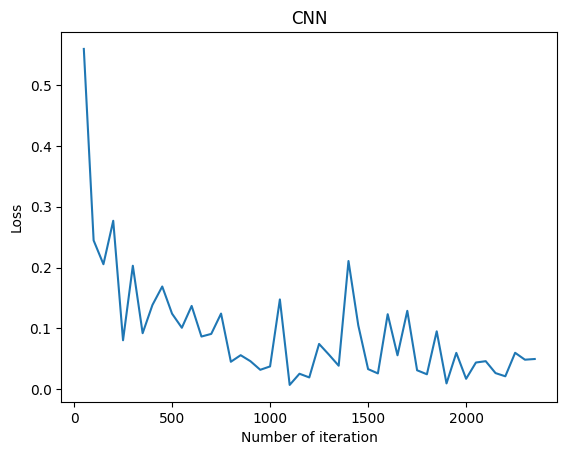

In [314]:
plt.plot(iteration_list, loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN")
plt.show()

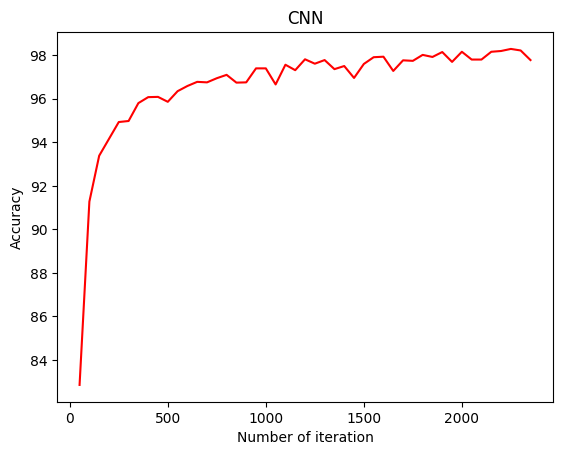

In [316]:
plt.plot(iteration_list, accuracy_list, color="red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN")
plt.show()